In [61]:
!pip install scikit-optimize


category
nonanimal    1210
animal       1190
Name: count, dtype: int64


/tmp/ipython-input-2737253100.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  accuracy_by_distance = df.groupby('distance')['correct'].mean()


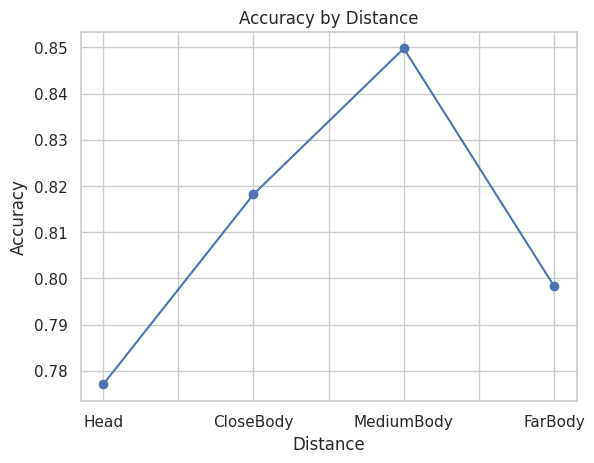

/tmp/ipython-input-2737253100.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rt_by_distance = df.groupby('distance')['reactionTime'].mean()


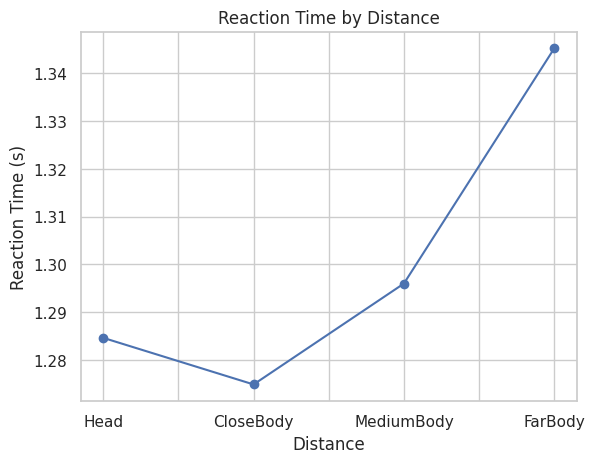

/tmp/ipython-input-2737253100.py:47: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  conf_by_distance = df.groupby('distance')['confidence'].mean()


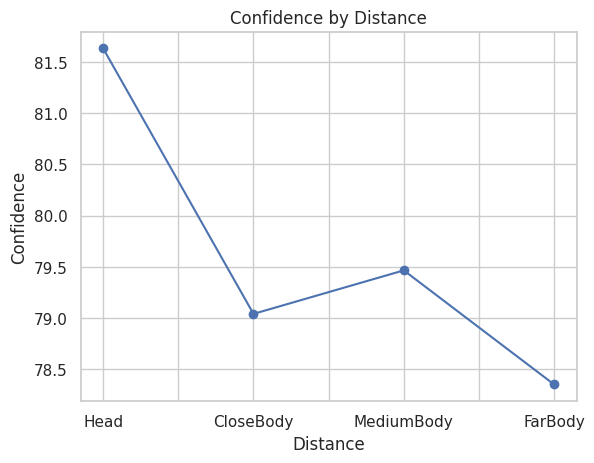

/tmp/ipython-input-2737253100.py:63: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  accuracy_by_category = df.groupby('category')['correct'].mean()
/tmp/ipython-input-2737253100.py:64: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rt_by_category = df.groupby('category')['reactionTime'].mean()
/tmp/ipython-input-2737253100.py:65: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  conf_by_category = df.groupby('category')['confi

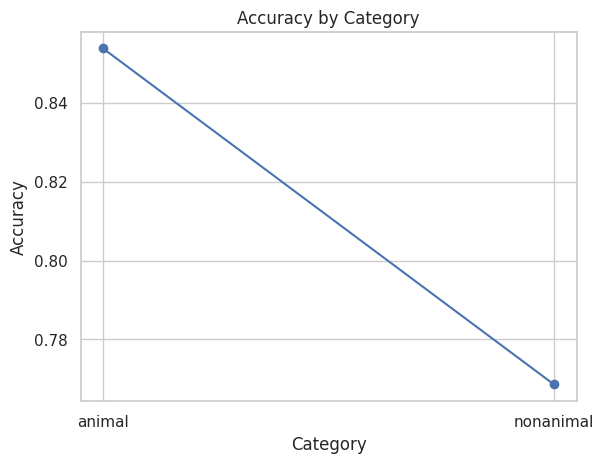

In [106]:
import pandas as pd
import matplotlib.pyplot as plt

filesmodel = ['/content/human_excels/finalresults.csv', '/content/human_excels/finalresults2.csv', '/content/human_excels/results1.csv', '/content/human_excels/results2.csv']

dfmodel = pd.concat([pd.read_csv(f) for f in filesmodel], ignore_index=True)

def clean_category(x):
    x = x.strip().lower()
    if x == 'animall':
        return 'animal'
    elif x == 'nonanimall':
        return 'nonanimal'
    else:
        return x

dfmodel['category'] = dfmodel['category'].apply(clean_category)
print(dfmodel['category'].value_counts())
dfmodel['correct'] = dfmodel['correct'].astype(int)
distance_order = ['Head','CloseBody', 'MediumBody', 'FarBody']
dfmodel['distance'] = pd.Categorical(dfmodel['distance'], categories=distance_order, ordered=True)



accuracy_by_distance = dfmodel.groupby('distance')['correct'].mean()
plt.figure()
accuracy_by_distance.plot(marker='o')
plt.title('Accuracy by Distance')
plt.ylabel('Accuracy')
plt.xlabel('Distance')
plt.grid(True)
plt.savefig('accuracy_by_distance.png')
plt.show()


rt_by_distance = dfmodel.groupby('distance')['reactionTime'].mean()
plt.figure()
rt_by_distance.plot(marker='o')
plt.title('Reaction Time by Distance')
plt.ylabel('Reaction Time (s)')
plt.xlabel('Distance')
plt.grid(True)
plt.savefig('reactiontime_by_distance.png')
plt.show()


conf_by_distance = dfmodel.groupby('distance')['confidence'].mean()
conf_by_distance = conf_by_distance * 20
plt.figure()
conf_by_distance.plot(marker='o')
plt.title('Confidence by Distance')
plt.ylabel('Confidence')
plt.xlabel('Distance')
plt.grid(True)
plt.savefig('confidence_by_distance.png')
plt.show()

import matplotlib.pyplot as plt
import matplotlib.pyplot as plt


dfmodel['category'] = pd.Categorical(dfmodel['category'], categories=['animal', 'nonanimal'], ordered=True)
accuracy_by_category = dfmodel.groupby('category')['correct'].mean()
rt_by_category = dfmodel.groupby('category')['reactionTime'].mean()
conf_by_category = dfmodel.groupby('category')['confidence'].mean()

categories = accuracy_by_category.index.tolist()


plt.figure()
plt.plot(categories, accuracy_by_category.values, marker='o')
plt.title('Accuracy by Category')
plt.xlabel('Category')
plt.ylabel('Accuracy')
plt.grid(True)
plt.savefig('accuracy_by_category.png')
plt.show()




/tmp/ipython-input-1513992787.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rt_correct = df[df['correct'] == 1].groupby('category')['reactionTime'].agg(['mean', 'sem'])
/tmp/ipython-input-1513992787.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rt_incorrect = df[df['correct'] == 0].groupby('category')['reactionTime'].agg(['mean', 'sem'])


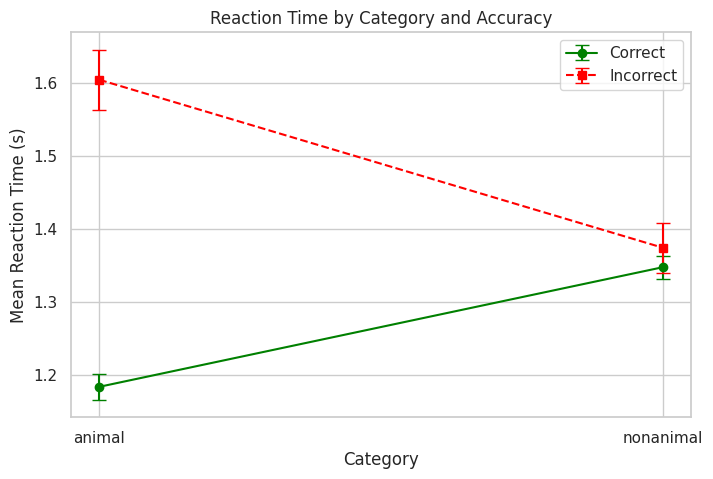

/tmp/ipython-input-1513992787.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  conf_correct = df[df['correct'] == 1].groupby('category')['confidence'].agg(['mean', 'sem'])
/tmp/ipython-input-1513992787.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  conf_incorrect = df[df['correct'] == 0].groupby('category')['confidence'].agg(['mean', 'sem'])


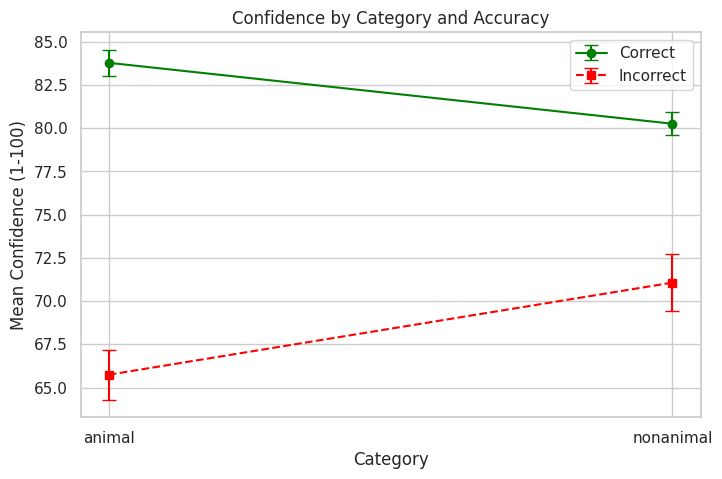

In [107]:
import matplotlib.pyplot as plt
import numpy as np

dfmodel['category'] = pd.Categorical(dfmodel['category'], categoriesmodel=['animal', 'nonanimal'], ordered=True)

categoriesmodel = ['animal', 'nonanimal']

rt_correct_model = dfmodel[dfmodel['correct'] == 1].groupby('category')['reactionTime'].agg(['mean', 'sem'])
rt_incorrect_model = dfmodel[dfmodel['correct'] == 0].groupby('category')['reactionTime'].agg(['mean', 'sem'])

plt.figure(figsize=(8,5))
plt.errorbar(categoriesmodel, _model.loc[categoriesmodel, 'mean'], yerr=_model.loc[categoriesmodel, 'sem'],
             fmt='o-', capsize=5, label='Correct', color='green')
plt.errorbar(categoriesmodel, _model.loc[categoriesmodel, 'mean'], yerr=_model.loc[categoriesmodel, 'sem'],
             fmt='s--', capsize=5, label='Incorrect', color='red')

plt.title('Reaction Time by Category and Accuracy')
plt.xlabel('Category')
plt.ylabel('Mean Reaction Time (s)')
plt.grid(True)
plt.legend()
plt.savefig('reactiontime_by_category.png')
plt.show()

dfmodel['category'] = pd.Categorical(dfmodel['category'], categoriesmodel=['animal', 'nonanimal'], ordered=True)

conf_correct = dfmodel[dfmodel['correct'] == 1].groupby('category')['confidence'].agg(['mean', 'sem'])
conf_incorrect = dfmodel[dfmodel['correct'] == 0].groupby('category')['confidence'].agg(['mean', 'sem'])

categoriesmodel = conf_correct.index.tolist()

conf_correct['mean'] *= 20
conf_correct['sem'] *= 20
conf_incorrect['mean'] *= 20
conf_incorrect['sem'] *= 20

plt.figure(figsize=(8,5))

plt.errorbar(categoriesmodel, conf_correct['mean'], yerr=conf_correct['sem'], fmt='o-', capsize=5, label='Correct', color='green')
plt.errorbar(categoriesmodel, conf_incorrect['mean'], yerr=conf_incorrect['sem'], fmt='s--', capsize=5, label='Incorrect', color='red')

plt.title('Confidence by Category and Accuracy')
plt.xlabel('Category')
plt.ylabel('Mean Confidence (1-100)')
plt.grid(True)
plt.legend()
plt.savefig('confidence_by_category.png')
plt.show()


